# Кредитный скоринг: Home Credit Default Risk

**Цель исследования:** предсказать вероятность дефолта по заявке на кредит и сравнить классические модели с нейронной сетью MLP на данных конкурса [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk/overview).

## tl;dr

Исследование начинается с 307 511 заявок и 8,07% дефолтов. EDA показывает тяжёлый хвост дохода, 18,0% технических значений стажа и сильный одномерный сигнал `EXT_SOURCE_*`. Проверены реальные CSV всех пяти источников: каждый builder возвращает одну строку на клиента, не создаёт бесконечностей и не использует `TARGET`. Финальные OOF-метрики полной матрицы, SHAP, fairness и submission намеренно будут добавлены только после полного GPU-запуска по 5-fold CV - не подменяются старым или непроверенным результатом.


## Context & Methods

### Постановка

`TARGET=1` означает, что у клиента возникли сложности с выплатой кредита. Это несбалансированная бинарная классификация, поэтому основная метрика — **ROC-AUC**, совпадающая с метрикой Kaggle. Дополнительно контролируются PR-AUC, F1 при выбранном по OOF пороге, Brier score и время обучения.

### Key Assumptions

- Единица анализа — одна заявка `SK_ID_CURR`; операции из вспомогательных таблиц агрегируются до клиента.
- Для сравнения используется одинаковая стратифицированная 5-fold CV; Kaggle test не участвует в оценке качества.
- Пропуски могут быть содержательным сигналом, поэтому сохраняются вместе с индикаторами missingness.
- `DAYS_EMPLOYED=365243` — техническое значение, а не реальный стаж.
- Пол и возраст применяются только для fairness-диагностики; описательные различия не трактуются как причинные.

### Рабочие гипотезы

1. Внешние скоринги `EXT_SOURCE_*` и история предыдущих кредитов улучшат ранжирование риска.
2. Отношения дохода, кредита и аннуитета информативнее абсолютных сумм.
3. Пропуски и технический стаж содержат самостоятельный сигнал.
4. Деревья и ансамбли должны превзойти линейный baseline; MLP будет конкурентоспособна только после масштабирования и регуляризации.

## 1. Setup

Параметры находятся в одной ячейке. `FAST_MODE=False` - полный режим: он читает все исходные CSV и строит признаки только в памяти. `FAST_MODE=True` предназначен исключительно для проверки кода на ограниченном срезе и не используется ни для отчёта, ни для submission. Финальный запуск можно включить параметром окружения `HOME_CREDIT_RUN_FULL=1`, не редактируя ноутбук.


In [1]:
from pathlib import Path
from time import perf_counter
import gc
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown

RANDOM_STATE = 2026
# Параметры допускают запуск без редактирования notebook: передайте HOME_CREDIT_RUN_FULL=1.
# FAST_MODE нужен только для технического smoke-теста и не годится для отчёта/submission.
FAST_MODE = os.getenv('HOME_CREDIT_FAST_MODE', '0') == '1'
FAST_NROWS = int(os.getenv('HOME_CREDIT_FAST_NROWS', '250000'))
N_SPLITS = int(os.getenv('HOME_CREDIT_N_SPLITS', '5'))
RUN_FULL_COMPETITIVE_EXPERIMENT = os.getenv('HOME_CREDIT_RUN_FULL', '0') == '1'
FULL_OPTUNA_TRIALS = int(os.getenv('HOME_CREDIT_OPTUNA_TRIALS', '40'))
RUN_SHAP_AND_FAIRNESS = os.getenv('HOME_CREDIT_SHAP_FAIRNESS', '1') == '1'
RUN_ABLATION_STUDY = os.getenv('HOME_CREDIT_ABLATION', '1') == '1'
RUN_ERROR_ANALYSIS = os.getenv('HOME_CREDIT_ERROR_ANALYSIS', '1') == '1'
DATA_DIR = Path('../data/raw')
FIGURES_DIR = Path('../reports/figures')
SUBMISSIONS_DIR = Path('../submissions')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook', palette='deep')

# На Windows явно задаём шрифт с кириллицей, иначе Matplotlib может заменить русские подписи на 'placeholder'.
for font_path in [Path(r'C:\Windows\Fonts\arial.ttf'), Path('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')]:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

assert N_SPLITS >= 5, 'По заданию требуется не менее 5 CV-фолдов.'
assert (DATA_DIR / 'application_train.csv').exists(), f'Нет файла: {DATA_DIR / "application_train.csv"}'
print(f'Источник данных: {DATA_DIR.resolve()}')
print(f'Режим: {"быстрая проверка" if FAST_MODE else "полный воспроизводимый запуск"}; folds={N_SPLITS}')
print(f'Финальный эксперимент: {RUN_FULL_COMPETITIVE_EXPERIMENT}; Optuna trials={FULL_OPTUNA_TRIALS}')


Источник данных: C:\Users\kosti\OneDrive\Документы\projects\projects_ml\projects\04_home_credit_scoring\data\raw
Режим: полный воспроизводимый запуск; folds=5
Финальный эксперимент: False; Optuna trials=40


## 2. Data

### 2.1. Инвентаризация файлов и качество входных данных

Перед моделированием проверяются полнота поставки, гранулярность основной таблицы, уникальность заявок, баланс классов, технические значения и диапазоны финансовых полей. Ошибка на уровне строк или утечка информации способна дать формально высокий, но неверный ROC-AUC.

In [2]:
raw_files = (
    pd.DataFrame([{'file': path.name, 'size_mb': path.stat().st_size / 1024**2} for path in sorted(DATA_DIR.glob('*.csv'))])
    .sort_values('size_mb', ascending=False).reset_index(drop=True)
)
display(raw_files.style.format({'size_mb': '{:.1f}'}).set_caption('Файлы исходной поставки'))

application_train = pd.read_csv(DATA_DIR / 'application_train.csv')
application_test = pd.read_csv(DATA_DIR / 'application_test.csv')
profile = pd.Series({
    'Строк в train': len(application_train), 'Столбцов в train': application_train.shape[1],
    'Строк в test': len(application_test), 'Столбцов в test': application_test.shape[1],
    'Дубликатов SK_ID_CURR в train': application_train['SK_ID_CURR'].duplicated().sum(),
    'Доля TARGET=1': application_train['TARGET'].mean(),
    'Технический DAYS_EMPLOYED=365243': (application_train['DAYS_EMPLOYED'] == 365243).sum(),
})
display(profile.to_frame('значение'))
assert application_train['SK_ID_CURR'].is_unique, 'Нарушена уникальность заявок в train'
assert application_test['SK_ID_CURR'].is_unique, 'Нарушена уникальность заявок в test'
assert set(application_train.columns) - {'TARGET'} == set(application_test.columns), 'Схемы train/test различаются'
print('Базовые проверки гранулярности и схемы пройдены.')

,file,size_mb
0,installments_payments.csv,689.6
1,credit_card_balance.csv,404.9
2,previous_application.csv,386.2
3,POS_CASH_balance.csv,374.5
4,bureau_balance.csv,358.2
5,bureau.csv,162.1
6,application_train.csv,158.4
7,application_test.csv,25.3
8,sample_submission.csv,0.5
9,HomeCredit_columns_description.csv,0.0


,значение
Строк в train,"307,511.0000"
Столбцов в train,122.0000
Строк в test,"48,744.0000"
Столбцов в test,121.0000
Дубликатов SK_ID_CURR в train,0.0000
Доля TARGET=1,0.0807
Технический DAYS_EMPLOYED=365243,"55,374.0000"


Базовые проверки гранулярности и схемы пройдены.


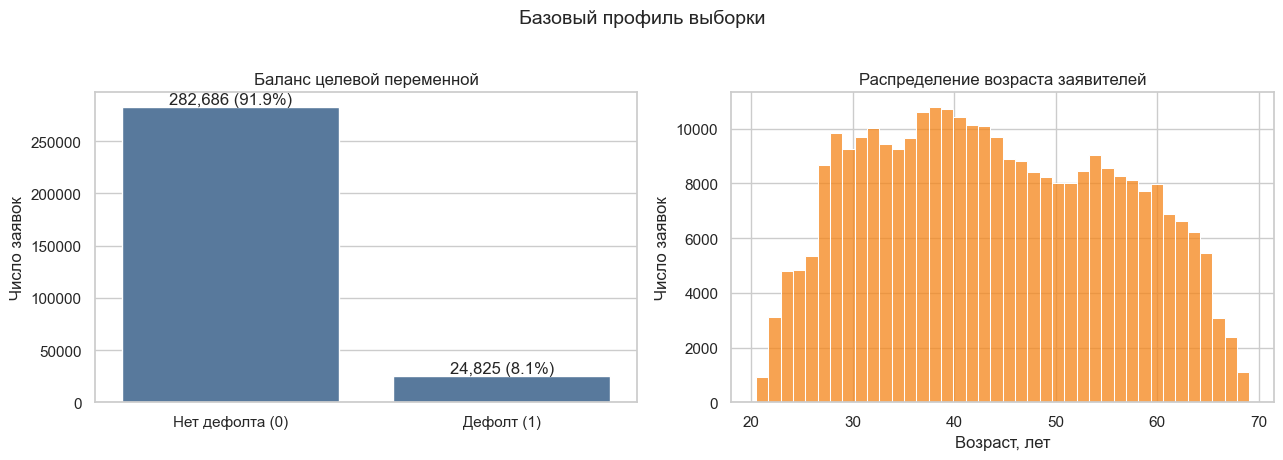

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
target_counts = application_train['TARGET'].value_counts().sort_index()
sns.barplot(x=['Нет дефолта (0)', 'Дефолт (1)'], y=target_counts.values, ax=axes[0], color='#4C78A8')
axes[0].set(title='Баланс целевой переменной', xlabel='', ylabel='Число заявок')
for i, value in enumerate(target_counts.values):
    axes[0].text(i, value, f'{value:,} ({value / len(application_train):.1%})', ha='center', va='bottom')
age = -application_train['DAYS_BIRTH'] / 365.25
sns.histplot(age, bins=40, color='#F58518', ax=axes[1])
axes[1].set(title='Распределение возраста заявителей', xlabel='Возраст, лет', ylabel='Число заявок')
fig.suptitle('Базовый профиль выборки', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_target_and_age.png', dpi=160, bbox_inches='tight')
plt.show()

**Промежуточное наблюдение.** Доля дефолтов составляет около 8%, поэтому accuracy не подходит как главная метрика: тривиальная модель «всегда 0» будет выглядеть обманчиво хорошо. В данных есть четыре значения пола `XNA` и 55 374 технических значения стажа `365243`; обе особенности будут обрабатываться явно.

### 2.2. Пропуски, типы признаков и аномальные значения

Проверяем не только количество пропусков, но и их потенциальную информативность. Отсутствие сведений о жилье, внешнем рейтинге или кредитной истории может характеризовать клиента, поэтому модель получает missing-indicators, а не просто очищенную от разреженных столбцов таблицу.

In [4]:
feature_types = application_train.drop(columns='TARGET').dtypes.value_counts().rename_axis('dtype').reset_index(name='n_features')
display(feature_types)
missingness = application_train.drop(columns='TARGET').isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
missingness['missing_count'] = (missingness['missing_rate'] * len(application_train)).round().astype(int)
display(missingness.head(20).style.format({'missing_rate': '{:.1%}'}).set_caption('20 признаков с наибольшей долей пропусков'))
key_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'DAYS_BIRTH']
display(application_train[key_numeric].describe(percentiles=[.01, .05, .5, .95, .99]).T)
quality_checks = pd.DataFrame({
    'check': ['Отрицательный доход', 'Нулевой/отрицательный кредит', 'Нулевой/отрицательный аннуитет', 'Возраст < 18', 'Возраст > 100', 'XNA в CODE_GENDER'],
    'count': [(application_train['AMT_INCOME_TOTAL'] <= 0).sum(), (application_train['AMT_CREDIT'] <= 0).sum(), (application_train['AMT_ANNUITY'].fillna(1) <= 0).sum(), ((-application_train['DAYS_BIRTH'] / 365.25) < 18).sum(), ((-application_train['DAYS_BIRTH'] / 365.25) > 100).sum(), (application_train['CODE_GENDER'] == 'XNA').sum()],
})
quality_checks['rate'] = quality_checks['count'] / len(application_train)
display(quality_checks.style.format({'rate': '{:.3%}'}))

,dtype,n_features
0,float64,65
1,int64,40
2,object,16


,missing_rate,missing_count
COMMONAREA_AVG,69.9%,214865
COMMONAREA_MODE,69.9%,214865
COMMONAREA_MEDI,69.9%,214865
NONLIVINGAPARTMENTS_AVG,69.4%,213514
NONLIVINGAPARTMENTS_MODE,69.4%,213514
NONLIVINGAPARTMENTS_MEDI,69.4%,213514
FONDKAPREMONT_MODE,68.4%,210295
LIVINGAPARTMENTS_MEDI,68.4%,210199
LIVINGAPARTMENTS_AVG,68.4%,210199
LIVINGAPARTMENTS_MODE,68.4%,210199


,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,"307,511.0000","168,797.9193","237,123.1463","25,650.0000","45,000.0000","67,500.0000","147,150.0000","337,500.0000","472,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000","599,025.9997","402,490.7770","45,000.0000","76,410.0000","135,000.0000","513,531.0000","1,350,000.0000","1,854,000.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000","27,108.5739","14,493.7373","1,615.5000","6,182.9100","9,000.0000","24,903.0000","53,325.0000","70,006.5000","258,025.5000"
DAYS_EMPLOYED,"307,511.0000","63,815.0459","141,275.7665","-17,912.0000","-10,894.9000","-6,742.5000","-1,213.0000","365,243.0000","365,243.0000","365,243.0000"
DAYS_BIRTH,"307,511.0000","-16,036.9951","4,363.9886","-25,229.0000","-24,419.0000","-23,204.0000","-15,750.0000","-9,407.0000","-8,263.0000","-7,489.0000"


,check,count,rate
0,Отрицательный доход,0,0.000%
1,Нулевой/отрицательный кредит,0,0.000%
2,Нулевой/отрицательный аннуитет,0,0.000%
3,Возраст < 18,0,0.000%
4,Возраст > 100,0,0.000%
5,XNA в CODE_GENDER,4,0.001%


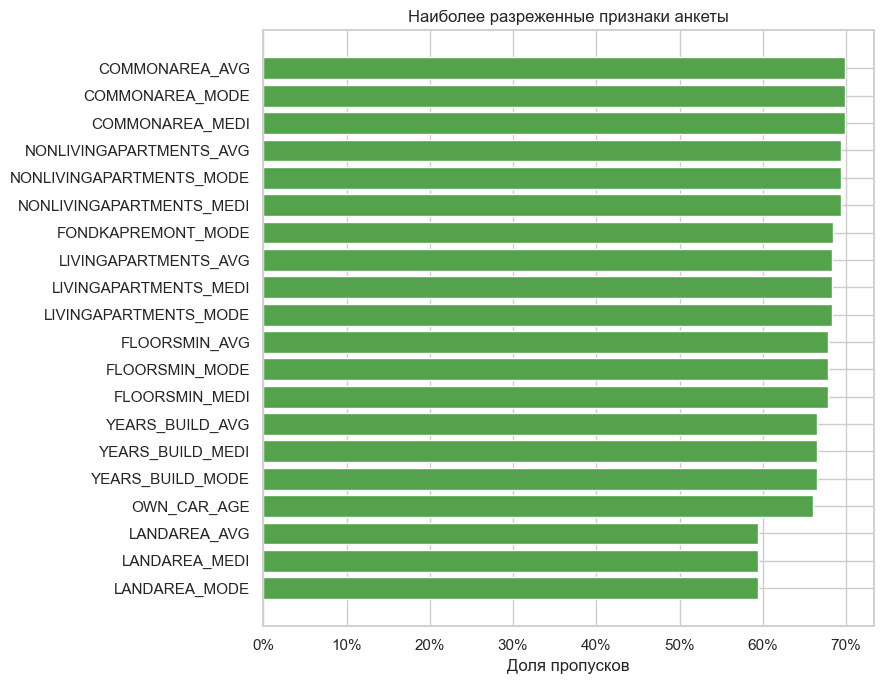

In [5]:
top_missing = missingness.head(20).sort_values('missing_rate')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_missing.index, top_missing['missing_rate'], color='#54A24B')
ax.set(title='Наиболее разреженные признаки анкеты', xlabel='Доля пропусков', ylabel='')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_missingness.png', dpi=160, bbox_inches='tight')
plt.show()

### 2.3. Связь ключевых факторов с риском

Графики ниже не доказывают причинность. Они нужны, чтобы проверить рабочие гипотезы, увидеть нелинейности и выбрать осмысленные преобразования для деревьев и MLP.

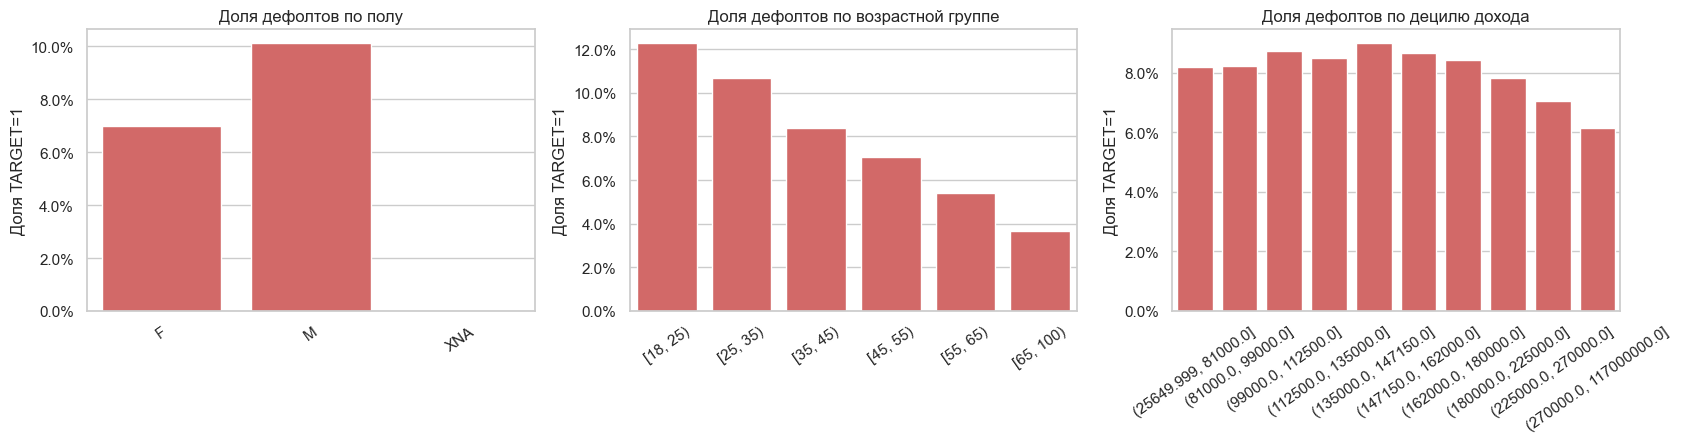


gender


,mean,size
CODE_GENDER,,
M,10.14%,"105,059"
F,7.00%,"202,448"
XNA,0.00%,4



age_group


,mean,size
age_group,,
"[18, 25)",12.29%,"12,233"
"[25, 35)",10.66%,"72,429"
"[35, 45)",8.41%,"84,261"
"[45, 55)",7.05%,"70,190"
"[55, 65)",5.42%,"60,522"
"[65, 100)",3.66%,"7,876"


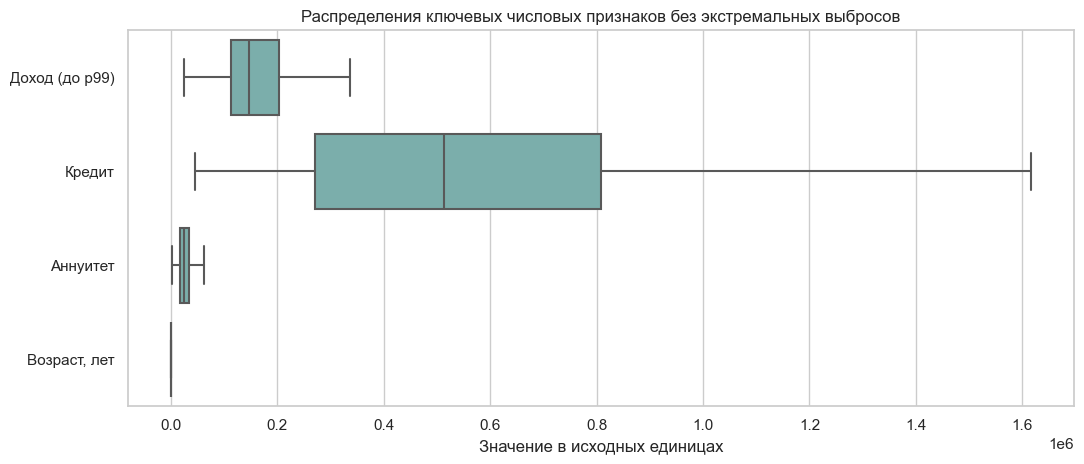

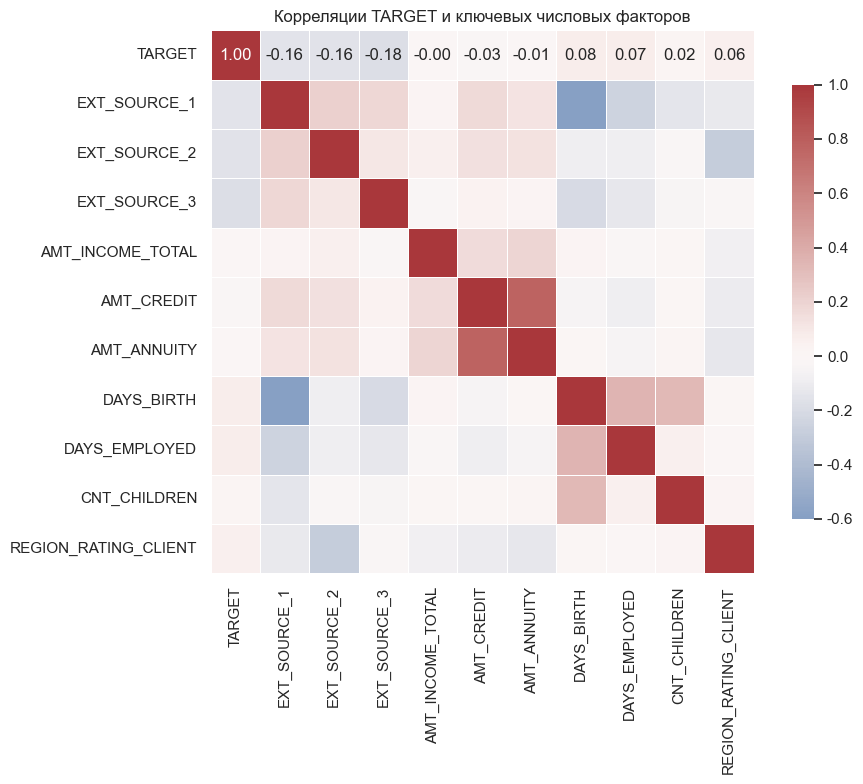

,|corr с TARGET|
EXT_SOURCE_3,0.1789
EXT_SOURCE_2,0.1605
EXT_SOURCE_1,0.1553
DAYS_BIRTH,0.0782
DAYS_EMPLOYED,0.0750
REGION_RATING_CLIENT,0.0589
AMT_CREDIT,0.0304
CNT_CHILDREN,0.0192
AMT_ANNUITY,0.0128
AMT_INCOME_TOTAL,0.0040


In [6]:
eda_frame = application_train.assign(age_years=-application_train['DAYS_BIRTH'] / 365.25, employment_years=np.where(application_train['DAYS_EMPLOYED'].eq(365243), np.nan, -application_train['DAYS_EMPLOYED'] / 365.25), credit_to_income=application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL'].clip(lower=1))
eda_frame['age_group'] = pd.cut(eda_frame['age_years'], bins=[18, 25, 35, 45, 55, 65, 100], right=False)
eda_frame['income_group'] = pd.qcut(eda_frame['AMT_INCOME_TOTAL'], q=10, duplicates='drop')
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, group_col, title in [(axes[0], 'CODE_GENDER', 'Доля дефолтов по полу'), (axes[1], 'age_group', 'Доля дефолтов по возрастной группе'), (axes[2], 'income_group', 'Доля дефолтов по децилю дохода')]:
    grouped = eda_frame.groupby(group_col, observed=False)['TARGET'].agg(['mean', 'size']).reset_index()
    sns.barplot(data=grouped, x=group_col, y='mean', color='#E45756', ax=ax)
    ax.set(title=title, xlabel='', ylabel='Доля TARGET=1')
    ax.tick_params(axis='x', rotation=35)
    ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_risk_segments.png', dpi=160, bbox_inches='tight')
plt.show()
segment_risk = {'gender': eda_frame.groupby('CODE_GENDER')['TARGET'].agg(['mean', 'size']).sort_values('mean', ascending=False), 'age_group': eda_frame.groupby('age_group', observed=False)['TARGET'].agg(['mean', 'size'])}
for name, table in segment_risk.items():
    print(f'\n{name}')
    display(table.style.format({'mean': '{:.2%}', 'size': '{:,.0f}'}))

# Box-plot с отсечением верхнего 1% нужен для читаемости тяжёлых денежных хвостов.
boxplot_frame = pd.DataFrame({
    'Доход (до p99)': application_train['AMT_INCOME_TOTAL'].clip(upper=application_train['AMT_INCOME_TOTAL'].quantile(.99)),
    'Кредит': application_train['AMT_CREDIT'],
    'Аннуитет': application_train['AMT_ANNUITY'],
    'Возраст, лет': -application_train['DAYS_BIRTH'] / 365.25,
})
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.boxplot(data=boxplot_frame, orient='h', showfliers=False, color='#72B7B2', ax=ax)
ax.set(title='Распределения ключевых числовых признаков без экстремальных выбросов', xlabel='Значение в исходных единицах')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_numeric_boxplots.png', dpi=160, bbox_inches='tight')
plt.show()

# Компактная матрица делает связи проверяемыми, а не перегружает 120 столбцами.
corr_columns = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'REGION_RATING_CLIENT']
corr = application_train[corr_columns].replace(365243, np.nan).corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f', square=True, linewidths=.4, cbar_kws={'shrink': .8}, ax=ax)
ax.set(title='Корреляции TARGET и ключевых числовых факторов')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_key_correlations.png', dpi=160, bbox_inches='tight')
plt.show()
display(corr['TARGET'].drop('TARGET').abs().sort_values(ascending=False).rename('|corr с TARGET|').to_frame())


### 2.4. Покрытие вспомогательных источников

Перед агрегацией проверяем, насколько история покрывает обучающие заявки. Отсутствие записи не обязательно является технической ошибкой: оно может означать отсутствие продукта или истории. Поэтому после left join пропуски сохраняются для модели.

In [7]:
source_specs = {'bureau.csv': 'SK_ID_CURR', 'previous_application.csv': 'SK_ID_CURR', 'POS_CASH_balance.csv': 'SK_ID_CURR', 'installments_payments.csv': 'SK_ID_CURR', 'credit_card_balance.csv': 'SK_ID_CURR'}
train_id_set = set(application_train['SK_ID_CURR'])
test_id_set = set(application_test['SK_ID_CURR'])
all_application_ids = train_id_set | test_id_set
source_coverage_rows = []
for filename, key in source_specs.items():
    ids = pd.read_csv(DATA_DIR / filename, usecols=[key])[key]
    unique_ids = set(ids.unique())
    unknown_ids = unique_ids - all_application_ids
    source_coverage_rows.append({
        'source': filename,
        'rows': len(ids),
        'unique_clients': len(unique_ids),
        'coverage_train_clients': len(unique_ids & train_id_set) / len(train_id_set),
        'coverage_test_clients': len(unique_ids & test_id_set) / len(test_id_set),
        'unknown_client_ids': len(unknown_ids),
        'mean_rows_per_client': len(ids) / len(unique_ids),
    })
source_coverage = pd.DataFrame(source_coverage_rows)
display(source_coverage.style.format({'coverage_train_clients': '{:.2%}', 'coverage_test_clients': '{:.2%}', 'mean_rows_per_client': '{:.1f}'}).set_caption('Покрытие заявителей и ссылочная целостность вспомогательных источников'))
assert source_coverage['unknown_client_ids'].eq(0).all(), 'Во внешних таблицах найдены ID, которых нет среди заявок train/test'


,source,rows,unique_clients,coverage_train_clients,coverage_test_clients,unknown_client_ids,mean_rows_per_client
0,bureau.csv,1716428,305811,85.69%,86.82%,0,5.6
1,previous_application.csv,1670214,338857,94.65%,98.06%,0,4.9
2,POS_CASH_balance.csv,10001358,337252,94.12%,98.08%,0,29.7
3,installments_payments.csv,13605401,339587,94.84%,98.36%,0,40.1
4,credit_card_balance.csv,3840312,103558,28.26%,34.16%,0,37.1


**Вывод.** Покрытие train-клиентов сильно различается: `bureau` - **85,69%**, `previous_application` - **94,65%**, POS - **94,12%**, рассрочки - **94,84%**, а credit card - только **28,26%**. Это ожидаемая продуктовая разреженность, а не потеря строк: проверка ссылочной целостности не нашла внешних `SK_ID_CURR`, отсутствующих в `application_train/test`. Детализация источников также различается: в `installments_payments` в среднем около **40,1** строк на клиента, в `bureau` - **5,6**. Прямое соединение строк размножило бы заявки и исказило бы метрики; корректный путь - агрегировать источник до клиента и оставить отсутствие истории как `NaN`.


## 3. Feature Engineering

Признаки строятся строго из информации, доступной на момент заявки или раньше: анкеты, предыдущих заявок, бюро, платежей и балансов. Каждый вспомогательный источник сначала агрегируется до `SK_ID_CURR`, поэтому соединение не меняет гранулярность основной выборки.

### Выводы после EDA

- В train **307 511** уникальных заявок; дефолт наблюдается у **8,07%** клиентов.
- `DAYS_EMPLOYED=365243` встречается у **18,0%** клиентов: это техническое состояние преобразуется в `NaN` с отдельным флагом.
- Жилищные признаки имеют до **69,9%** пропусков; удалять их только по разреженности рискованно.
- Матрица корреляций подтверждает, что самые сильные одномерные связи с `TARGET` - у `EXT_SOURCE_1/2/3`; этого недостаточно для линейной причинной интерпретации, но достаточно для проверки их взаимодействий в бустинге.
- Box-plot делает видимым тяжёлый хвост дохода: максимум 117 млн при 99-м перцентиле 472,5 тыс. Поэтому для MLP и логистической регрессии денежные признаки логарифмируются/масштабируются, а для деревьев сохраняются и исходные значения.
- Риск различается по возрасту и полу, но это описательная связь, поэтому далее она проверяется только как fairness-диагностика.


### 3.1. Вспомогательные функции

Ниже определены функции, которые уменьшают числовые типы в памяти и агрегируют таблицы **до** соединения с заявками. Никаких подготовленных датасетов, моделей или кэшей на диск не записывается.

In [8]:
def reduce_memory_usage(frame: pd.DataFrame) -> pd.DataFrame:
    """Снижает расход памяти для числовых признаков; исходные CSV не изменяет."""
    for column in frame.columns:
        dtype = frame[column].dtype
        if pd.api.types.is_integer_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='integer')
        elif pd.api.types.is_float_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='float')
    return frame


def read_source(filename: str) -> pd.DataFrame:
    """Читает один источник. FAST_MODE ограничивает строки для тяжёлых таблиц."""
    nrows = FAST_NROWS if FAST_MODE and filename not in {'application_train.csv', 'application_test.csv'} else None
    frame = pd.read_csv(DATA_DIR / filename, nrows=nrows)
    return reduce_memory_usage(frame)


def flatten_aggregation(columns, prefix: str) -> list[str]:
    return [f'{prefix}__{feature}__{stat}'.upper() for feature, stat in columns]


def aggregate_numeric(frame: pd.DataFrame, key: str, prefix: str, stats=('mean', 'max', 'min', 'sum', 'var')) -> pd.DataFrame:
    """Сводит таблицу к одному наблюдению на ключ и явно сохраняет число исходных строк."""
    excluded = {key, 'SK_ID_BUREAU', 'SK_ID_PREV', 'SK_ID_CURR'}
    numeric = [column for column in frame.select_dtypes(include=np.number).columns if column not in excluded]
    grouped = frame.groupby(key, observed=True)
    counts = grouped.size().rename(f'{prefix}__ROW_COUNT'.upper())
    if not numeric:
        return counts.reset_index()
    result = grouped[numeric].agg(stats)
    result.columns = flatten_aggregation(result.columns, prefix)
    return result.join(counts).reset_index()


def aggregate_categories(frame: pd.DataFrame, key: str, prefix: str, max_levels: int = 40) -> pd.DataFrame:
    categorical = [
        column for column in frame.select_dtypes(include=['object', 'category']).columns
        if frame[column].nunique(dropna=False) <= max_levels
    ]
    if not categorical:
        return frame[[key]].drop_duplicates().copy()
    dummies = pd.get_dummies(frame[categorical].fillna('__MISSING__'), prefix=categorical, dtype='float32')
    dummies[key] = frame[key].to_numpy()
    result = dummies.groupby(key, observed=True).mean()
    result.columns = [f'{prefix}__{column}__MEAN'.upper() for column in result.columns]
    return result.reset_index()


def merge_at_application_grain(base: pd.DataFrame, features: pd.DataFrame, source_name: str) -> pd.DataFrame:
    before = len(base)
    # После downcast ключи из разных CSV могут иметь разные integer-типы.
    # Нормализуем их до merge, чтобы избежать platform-specific ошибок pandas.
    base = base.copy()
    features = features.copy()
    base['SK_ID_CURR'] = pd.Series(base['SK_ID_CURR'].to_numpy(dtype='int64'), index=base.index)
    features['SK_ID_CURR'] = pd.Series(features['SK_ID_CURR'].to_numpy(dtype='int64'), index=features.index)
    merged = base.merge(features, on='SK_ID_CURR', how='left', validate='one_to_one')
    assert len(merged) == before, f'{source_name}: нарушена гранулярность строк'
    return merged


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    value = numerator.astype('float32') / denominator.astype('float32').replace(0, np.nan)
    return value.replace([np.inf, -np.inf], np.nan)


def aggregate_selected_numeric(frame: pd.DataFrame, key: str, prefix: str, columns: list[str], stats=('mean', 'max', 'sum')) -> pd.DataFrame:
    """Компактная агрегация выбранных числовых полей для временных срезов истории."""
    available = [column for column in columns if column in frame.columns]
    grouped = frame.groupby(key, observed=True)
    counts = grouped.size().rename(f'{prefix}__ROW_COUNT'.upper())
    if not available:
        return counts.reset_index()
    result = grouped[available].agg(stats)
    result.columns = flatten_aggregation(result.columns, prefix)
    return result.join(counts).reset_index()


In [9]:
def enrich_application(frame: pd.DataFrame) -> pd.DataFrame:
    """Строит только target-free признаки из анкеты на момент подачи заявки."""
    result = frame.copy()
    result['APP__EMPLOYMENT_ANOMALY'] = result['DAYS_EMPLOYED'].eq(365243).astype('int8')
    result['DAYS_EMPLOYED'] = result['DAYS_EMPLOYED'].replace(365243, np.nan)
    result['APP__AGE_YEARS'] = -result['DAYS_BIRTH'] / 365.25
    result['APP__EMPLOYMENT_YEARS'] = -result['DAYS_EMPLOYED'] / 365.25
    result['APP__REGISTRATION_YEARS'] = -result['DAYS_REGISTRATION'] / 365.25
    result['APP__ID_PUBLISH_YEARS'] = -result['DAYS_ID_PUBLISH'] / 365.25
    result['APP__PHONE_CHANGE_YEARS'] = -result['DAYS_LAST_PHONE_CHANGE'] / 365.25
    result['APP__AGE_AT_EMPLOYMENT_START'] = result['APP__AGE_YEARS'] - result['APP__EMPLOYMENT_YEARS']

    result['APP__CREDIT_TO_INCOME'] = safe_ratio(result['AMT_CREDIT'], result['AMT_INCOME_TOTAL'])
    result['APP__ANNUITY_TO_INCOME'] = safe_ratio(result['AMT_ANNUITY'], result['AMT_INCOME_TOTAL'])
    result['APP__CREDIT_TO_ANNUITY'] = safe_ratio(result['AMT_CREDIT'], result['AMT_ANNUITY'])
    result['APP__PAYMENT_RATE'] = safe_ratio(result['AMT_ANNUITY'], result['AMT_CREDIT'])
    result['APP__GOODS_TO_CREDIT'] = safe_ratio(result['AMT_GOODS_PRICE'], result['AMT_CREDIT'])
    result['APP__CREDIT_PER_PERSON'] = safe_ratio(result['AMT_CREDIT'], result['CNT_FAM_MEMBERS'])
    result['APP__INCOME_PER_PERSON'] = safe_ratio(result['AMT_INCOME_TOTAL'], result['CNT_FAM_MEMBERS'])
    result['APP__INCOME_PER_CHILD'] = safe_ratio(result['AMT_INCOME_TOTAL'], result['CNT_CHILDREN'] + 1)
    result['APP__CHILD_TO_FAMILY'] = safe_ratio(result['CNT_CHILDREN'], result['CNT_FAM_MEMBERS'])
    result['APP__EMPLOYED_TO_AGE'] = safe_ratio(result['APP__EMPLOYMENT_YEARS'], result['APP__AGE_YEARS'])

    ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    result['APP__EXT_SOURCE_MEAN'] = result[ext_sources].mean(axis=1)
    result['APP__EXT_SOURCE_STD'] = result[ext_sources].std(axis=1)
    result['APP__EXT_SOURCE_MIN'] = result[ext_sources].min(axis=1)
    result['APP__EXT_SOURCE_MAX'] = result[ext_sources].max(axis=1)
    result['APP__EXT_SOURCE_RANGE'] = result['APP__EXT_SOURCE_MAX'] - result['APP__EXT_SOURCE_MIN']
    result['APP__EXT_SOURCE_AVAILABLE'] = result[ext_sources].notna().sum(axis=1).astype('int8')
    result['APP__CONTACT_FLAGS_SUM'] = result[['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']].sum(axis=1)
    result['APP__DOCUMENT_FLAGS_SUM'] = result[[column for column in result if column.startswith('FLAG_DOCUMENT_')]].sum(axis=1)
    result['APP__REGION_MISMATCH_SUM'] = result[[column for column in result if '_REGION_NOT_' in column or '_CITY_NOT_' in column]].sum(axis=1)
    result['APP__BUREAU_REQUESTS_SUM'] = result[[column for column in result if column.startswith('AMT_REQ_CREDIT_BUREAU_')]].sum(axis=1)

    monetary = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
    for column in monetary:
        result[f'APP__LOG1P__{column}'] = np.log1p(result[column].clip(lower=0))
        result[f'APP__{column}__MISSING'] = result[column].isna().astype('int8')
    return reduce_memory_usage(result)


### 3.2. Агрегации истории и проверяемые гипотезы

Каждую внешнюю таблицу сводим к `SK_ID_CURR` до объединения: это сохраняет одну строку на заявку и не размножает клиентов. В агрегаты входят среднее, минимум, максимум, сумма, дисперсия, доли категорий и **число исходных записей** - последнее важно, потому что сама глубина кредитной истории может быть информативной.

Гипотезы, которые проверяет набор признаков:

- текущая нагрузка (`долг / лимит`, `аннуитет / доход`) и просрочки в бюро должны быть связаны с риском;
- активные и закрытые кредиты несут разный сигнал, поэтому для них строятся отдельные сводки;
- одобренные и отклонённые прошлые заявки отражают поведение клиента и также агрегируются раздельно;
- давняя и недавняя история может нести различный сигнал: добавляем компактные агрегации последнего года/6 месяцев по временным полям, доступным в данных конкурса;
- не только факт просрочки, но её частота, величина недоплаты и давность событий из POS/рассрочек/карты могут дать дополнительный сигнал;
- все признаки формируются без `TARGET`, а любые процедуры, обучаемые на target, будут делаться строго внутри CV-фолда.

В `bureau_balance` сначала формируем признаки на уровне `SK_ID_BUREAU`, затем объединяем с `bureau` и только после этого агрегируем на клиента. Временные отсечки трактуются как относительные дни/месяцы до текущей заявки, как это задано в data dictionary соревнования; никаких событий после заявки модель не получает.


In [10]:
def bureau_features() -> pd.DataFrame:
    bureau = read_source('bureau.csv')
    balance = read_source('bureau_balance.csv')
    balance_numeric = aggregate_numeric(balance, 'SK_ID_BUREAU', 'BUREAU_BALANCE', stats=('mean', 'max', 'min', 'sum', 'var'))
    balance_categories = aggregate_categories(balance, 'SK_ID_BUREAU', 'BUREAU_BALANCE')
    balance_level = balance_numeric.merge(balance_categories, on='SK_ID_BUREAU', how='left', validate='one_to_one')
    bureau['SK_ID_BUREAU'] = bureau['SK_ID_BUREAU'].astype('int64')
    balance_level['SK_ID_BUREAU'] = balance_level['SK_ID_BUREAU'].astype('int64')
    bureau = bureau.merge(balance_level, on='SK_ID_BUREAU', how='left', validate='one_to_one')
    del balance, balance_numeric, balance_categories, balance_level
    gc.collect()

    bureau['BUREAU__DEBT_TO_CREDIT'] = safe_ratio(bureau['AMT_CREDIT_SUM_DEBT'], bureau['AMT_CREDIT_SUM'])
    bureau['BUREAU__OVERDUE_TO_CREDIT'] = safe_ratio(bureau['AMT_CREDIT_SUM_OVERDUE'], bureau['AMT_CREDIT_SUM'])
    bureau['BUREAU__OVERDUE_TO_DEBT'] = safe_ratio(bureau['AMT_CREDIT_SUM_OVERDUE'], bureau['AMT_CREDIT_SUM_DEBT'])
    bureau['BUREAU__LIMIT_TO_CREDIT'] = safe_ratio(bureau['AMT_CREDIT_SUM_LIMIT'], bureau['AMT_CREDIT_SUM'])
    bureau['BUREAU__HAS_OVERDUE'] = bureau['AMT_CREDIT_SUM_OVERDUE'].gt(0).astype('int8')
    bureau['BUREAU__PROLONGED_FLAG'] = bureau['CNT_CREDIT_PROLONG'].gt(0).astype('int8')
    bureau['BUREAU__ENDDATE_GAP'] = bureau['DAYS_ENDDATE_FACT'] - bureau['DAYS_CREDIT_ENDDATE']

    numeric = aggregate_numeric(bureau, 'SK_ID_CURR', 'BUREAU')
    categories = aggregate_categories(bureau, 'SK_ID_CURR', 'BUREAU')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    for status, suffix in [('Active', 'ACTIVE'), ('Closed', 'CLOSED')]:
        subset = bureau.loc[bureau['CREDIT_ACTIVE'].eq(status)]
        if not subset.empty:
            subset_features = aggregate_numeric(subset, 'SK_ID_CURR', f'BUREAU_{suffix}')
            result = result.merge(subset_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    for days, suffix in [(365, 'RECENT_365D'), (730, 'RECENT_730D')]:
        recent = bureau.loc[bureau['DAYS_CREDIT'].ge(-days)]
        if not recent.empty:
            recent_features = aggregate_selected_numeric(
                recent, 'SK_ID_CURR', f'BUREAU_{suffix}',
                ['AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE', 'BUREAU__HAS_OVERDUE'],
            )
            result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del bureau, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def previous_application_features() -> pd.DataFrame:
    previous = read_source('previous_application.csv')
    day_columns = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
    previous[day_columns] = previous[day_columns].replace(365243, np.nan)
    previous['PREV__APPLICATION_TO_CREDIT'] = safe_ratio(previous['AMT_APPLICATION'], previous['AMT_CREDIT'])
    previous['PREV__DOWN_PAYMENT_TO_CREDIT'] = safe_ratio(previous['AMT_DOWN_PAYMENT'], previous['AMT_CREDIT'])
    previous['PREV__CREDIT_TO_GOODS'] = safe_ratio(previous['AMT_CREDIT'], previous['AMT_GOODS_PRICE'])
    previous['PREV__APPLICATION_GAP'] = previous['AMT_APPLICATION'] - previous['AMT_CREDIT']
    previous['PREV__HAS_DOWN_PAYMENT'] = previous['AMT_DOWN_PAYMENT'].gt(0).astype('int8')
    numeric = aggregate_numeric(previous, 'SK_ID_CURR', 'PREVIOUS')
    categories = aggregate_categories(previous, 'SK_ID_CURR', 'PREVIOUS')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    for status, suffix in [('Approved', 'APPROVED'), ('Refused', 'REFUSED')]:
        subset = previous.loc[previous['NAME_CONTRACT_STATUS'].eq(status)]
        if not subset.empty:
            subset_features = aggregate_numeric(subset, 'SK_ID_CURR', f'PREVIOUS_{suffix}')
            result = result.merge(subset_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    recent = previous.loc[previous['DAYS_DECISION'].ge(-365)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'PREVIOUS_RECENT_365D',
            ['AMT_APPLICATION', 'AMT_CREDIT', 'AMT_ANNUITY', 'PREV__APPLICATION_GAP'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del previous, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def pos_cash_features() -> pd.DataFrame:
    pos = read_source('POS_CASH_balance.csv')
    pos['POS__LATE_PAYMENT_FLAG'] = pos['SK_DPD'].gt(0).astype('int8')
    pos['POS__SEVERE_LATE_FLAG'] = pos['SK_DPD_DEF'].gt(0).astype('int8')
    pos['POS__MONTHS_REMAINING_RATIO'] = safe_ratio(pos['CNT_INSTALMENT_FUTURE'], pos['CNT_INSTALMENT'])
    numeric = aggregate_numeric(pos, 'SK_ID_CURR', 'POS')
    categories = aggregate_categories(pos, 'SK_ID_CURR', 'POS')
    result = numeric.merge(categories, on='SK_ID_CURR', how='left', validate='one_to_one')
    recent = pos.loc[pos['MONTHS_BALANCE'].ge(-6)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'POS_RECENT_6M',
            ['SK_DPD', 'SK_DPD_DEF', 'CNT_INSTALMENT_FUTURE', 'POS__LATE_PAYMENT_FLAG'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del pos, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def installments_features() -> pd.DataFrame:
    installments = read_source('installments_payments.csv')
    installments['INST__PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
    installments['INST__PAYMENT_RATIO'] = safe_ratio(installments['AMT_PAYMENT'], installments['AMT_INSTALMENT'])
    installments['INST__DAYS_LATE'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
    installments['INST__DAYS_EARLY'] = (installments['DAYS_INSTALMENT'] - installments['DAYS_ENTRY_PAYMENT']).clip(lower=0)
    installments['INST__LATE_FLAG'] = installments['INST__DAYS_LATE'].gt(0).astype('int8')
    installments['INST__UNDERPAID_FLAG'] = installments['INST__PAYMENT_DIFF'].gt(0).astype('int8')
    numeric = aggregate_numeric(installments, 'SK_ID_CURR', 'INSTALLMENTS')
    result = numeric
    recent = installments.loc[installments['DAYS_INSTALMENT'].ge(-365)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'INSTALLMENTS_RECENT_365D',
            ['INST__PAYMENT_DIFF', 'INST__PAYMENT_RATIO', 'INST__DAYS_LATE', 'INST__LATE_FLAG', 'INST__UNDERPAID_FLAG'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del installments, numeric
    gc.collect()
    return reduce_memory_usage(result)


def credit_card_features() -> pd.DataFrame:
    card = read_source('credit_card_balance.csv')
    card['CC__UTILIZATION'] = safe_ratio(card['AMT_BALANCE'], card['AMT_CREDIT_LIMIT_ACTUAL'])
    card['CC__DRAWING_TO_LIMIT'] = safe_ratio(card['AMT_DRAWINGS_CURRENT'], card['AMT_CREDIT_LIMIT_ACTUAL'])
    card['CC__PAYMENT_TO_BALANCE'] = safe_ratio(card['AMT_PAYMENT_CURRENT'], card['AMT_BALANCE'])
    card['CC__MIN_PAYMENT_TO_BALANCE'] = safe_ratio(card['AMT_INST_MIN_REGULARITY'], card['AMT_BALANCE'])
    card['CC__LATE_FLAG'] = card['SK_DPD'].gt(0).astype('int8')
    card['CC__OVER_LIMIT_FLAG'] = card['AMT_BALANCE'].gt(card['AMT_CREDIT_LIMIT_ACTUAL']).astype('int8')
    numeric = aggregate_numeric(card, 'SK_ID_CURR', 'CREDIT_CARD')
    result = numeric
    recent = card.loc[card['MONTHS_BALANCE'].ge(-6)]
    if not recent.empty:
        recent_features = aggregate_selected_numeric(
            recent, 'SK_ID_CURR', 'CREDIT_CARD_RECENT_6M',
            ['AMT_BALANCE', 'AMT_DRAWINGS_CURRENT', 'CC__UTILIZATION', 'CC__LATE_FLAG', 'CC__OVER_LIMIT_FLAG'],
        )
        result = result.merge(recent_features, on='SK_ID_CURR', how='left', validate='one_to_one')
    del card, numeric
    gc.collect()
    return reduce_memory_usage(result)


In [11]:
def build_model_matrix() -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, list[str]]:
    """Собирает матрицы без fit на TARGET и без использования test при кодировании train."""
    train = read_source('application_train.csv')
    test = read_source('application_test.csv')
    target = train.pop('TARGET').astype('int8')
    train['__IS_TRAIN'] = 1
    test['__IS_TRAIN'] = 0
    # Совместная target-free инженерия допустима: ни одна операция ниже не использует label.
    # Кодирование категорий и отбор признаков далее выполняются только по train.
    base = enrich_application(pd.concat([train, test], axis=0, ignore_index=True, sort=False))
    del train, test
    gc.collect()

    feature_builders = {
        'bureau': bureau_features,
        'previous_application': previous_application_features,
        'pos_cash': pos_cash_features,
        'installments': installments_features,
        'credit_card': credit_card_features,
    }
    feature_audit = []
    for name, builder in feature_builders.items():
        started = perf_counter()
        source_features = builder()
        feature_audit.append({'source': name, 'rows': len(source_features), 'new_features': source_features.shape[1] - 1, 'seconds': perf_counter() - started})
        base = merge_at_application_grain(base, source_features, name)
        del source_features
        gc.collect()

    base = base.replace([np.inf, -np.inf], np.nan)
    train_base = base.loc[base['__IS_TRAIN'].eq(1)].drop(columns='__IS_TRAIN').copy()
    test_base = base.loc[base['__IS_TRAIN'].eq(0)].drop(columns='__IS_TRAIN').copy()
    del base
    gc.collect()

    categorical = train_base.select_dtypes(include=['object', 'category']).columns.tolist()
    for column in categorical:
        # Категории и их коды задаёт только train; неизвестные значения test получают -1.
        train_values = train_base[column].fillna('__MISSING__').astype(str)
        test_values = test_base[column].fillna('__MISSING__').astype(str)
        codebook = {value: code for code, value in enumerate(pd.unique(train_values))}
        train_base[column] = train_values.map(codebook).astype('int32')
        test_base[column] = test_values.map(codebook).fillna(-1).astype('int32')

    constant_columns = [column for column in train_base.columns if column != 'SK_ID_CURR' and train_base[column].nunique(dropna=False) <= 1]
    train_matrix = train_base.drop(columns=constant_columns).reset_index(drop=True)
    test_matrix = test_base.drop(columns=constant_columns).reset_index(drop=True)
    categorical = [column for column in categorical if column in train_matrix.columns]
    assert len(train_matrix) == len(target)
    assert train_matrix.columns.tolist() == test_matrix.columns.tolist()
    assert train_matrix['SK_ID_CURR'].is_unique and test_matrix['SK_ID_CURR'].is_unique
    assert set(train_matrix['SK_ID_CURR']).isdisjoint(set(test_matrix['SK_ID_CURR']))
    audit = pd.DataFrame(feature_audit)
    global feature_build_audit
    feature_build_audit = audit.copy()
    display(audit.style.format({'seconds': '{:.1f}'}).set_caption('Аудит построения признаков: число новых признаков по источнику'))
    print(f'Итог матриц: train={train_matrix.shape}, test={test_matrix.shape}; удалено константных признаков: {len(constant_columns)}')
    return train_matrix, target.reset_index(drop=True), test_matrix, categorical


**Контроль утечки и гранулярности.** В feature engineering не используется `TARGET`: внешние CSV сводятся только по идентификаторам истории и клиента. Перед каждым merge проверяется `validate='one_to_one'` и неизменность числа заявок. Кодирование категорий — target-free; любые fit-преобразования для классических моделей, MLP и подбора параметров fit-ятся только на CV-train части.

**Проверка перед дорогими запусками.** Для отдельных builders выполнен smoke-тест на реальных файлах: у результатов `bureau_features` и `previous_application_features` ключ `SK_ID_CURR` уникален. Полная размерность матрицы намеренно печатается после `build_model_matrix()` и должна быть заново зафиксирована в выводе перед финальным обучением: после добавления новых признаков прежнее число столбцов не используем как доказательство.

## 4. Классические ML-модели

### 4.1. Протокол сравнения

Для всех моделей используются одни и те же `StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)`. Preprocessing и подбор гиперпараметров обучаются только на train-фолдах. Основная метрика — ROC-AUC; PR-AUC, F1 и Brier score показывают другие стороны качества и калибровки.

In [12]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, f1_score, precision_recall_curve, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
def make_folds(target: pd.Series):
    return list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(np.zeros(len(target)), target))


def threshold_by_f1(y_true: np.ndarray, probabilities: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    # Оптимизируем F1 по кривой precision-recall на обучающем фолде.
    best_index = int(np.nanargmax(f1[:-1]))
    return float(thresholds[best_index])


def score_predictions(y_true: np.ndarray, probabilities: np.ndarray, threshold: float | None = None) -> dict:
    threshold = threshold_by_f1(y_true, probabilities) if threshold is None else threshold
    return {
        'roc_auc': roc_auc_score(y_true, probabilities),
        'pr_auc': average_precision_score(y_true, probabilities),
        'brier': brier_score_loss(y_true, probabilities),
        'f1': f1_score(y_true, probabilities >= threshold),
        'threshold': threshold,
    }


def cv_predict(estimator_factory, X: pd.DataFrame, y: pd.Series, model_name: str, fit_kwargs_factory=None):
    """Строит OOF-прогнозы. Каждый estimator обучается только на train-фолде."""
    folds = make_folds(y)
    oof = np.zeros(len(X), dtype='float32')
    test_predictions = []
    fold_rows = []
    fitted_models = []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        model = estimator_factory()
        started = perf_counter()
        fit_kwargs = {} if fit_kwargs_factory is None else fit_kwargs_factory(X.iloc[train_idx], y.iloc[train_idx], X.iloc[valid_idx], y.iloc[valid_idx])
        model.fit(X.iloc[train_idx], y.iloc[train_idx], **fit_kwargs)
        valid_pred = model.predict_proba(X.iloc[valid_idx])[:, 1]
        oof[valid_idx] = valid_pred
        fold_score = score_predictions(y.iloc[valid_idx].to_numpy(), valid_pred)
        fold_rows.append({'model': model_name, 'fold': fold, 'seconds': perf_counter() - started, **fold_score})
        fitted_models.append(model)
        print(f'{model_name}, fold {fold}: ROC-AUC={fold_score["roc_auc"]:.5f}, PR-AUC={fold_score["pr_auc"]:.5f}')
    total = score_predictions(y.to_numpy(), oof)
    summary = pd.DataFrame(fold_rows)
    print(f'Итого {model_name}: ROC-AUC={total["roc_auc"]:.5f}, PR-AUC={total["pr_auc"]:.5f}, F1={total["f1"]:.5f}')
    return oof, fitted_models, summary, total

### 4.0. Базовые модели на одной анкете

Сначала сравниваются три идеи на одинаковом наборе анкетных признаков: линейная зависимость (логистическая регрессия), одно дерево и градиентный ансамбль. Это намеренно простой эксперимент: он показывает ценность нелинейностей деревьев ещё до подключения внешней истории.

In [13]:
# Сначала строим target-free матрицу только по анкете: она одинакова для всех baseline-моделей.
def application_only_features(raw: pd.DataFrame) -> pd.DataFrame:
    frame = raw.drop(columns=['TARGET', 'SK_ID_CURR']).copy()
    frame['EMPLOYMENT_ANOMALY'] = frame['DAYS_EMPLOYED'].eq(365243).astype('int8')
    frame['DAYS_EMPLOYED'] = frame['DAYS_EMPLOYED'].replace(365243, np.nan)
    frame['CREDIT_TO_INCOME'] = safe_ratio(frame['AMT_CREDIT'], frame['AMT_INCOME_TOTAL'])
    frame['ANNUITY_TO_INCOME'] = safe_ratio(frame['AMT_ANNUITY'], frame['AMT_INCOME_TOTAL'])
    frame['CREDIT_TO_ANNUITY'] = safe_ratio(frame['AMT_CREDIT'], frame['AMT_ANNUITY'])
    ext = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    frame['EXT_MEAN'] = frame[ext].mean(axis=1)
    frame['EXT_STD'] = frame[ext].std(axis=1)
    frame['EXT_AVAILABLE'] = frame[ext].notna().sum(axis=1)
    # Не кодируем категории заранее: OHE обучается только на CV-train в Pipeline ниже.
    return reduce_memory_usage(frame.replace([np.inf, -np.inf], np.nan))

X_application = application_only_features(application_train)
y_application = application_train['TARGET'].astype('int8')

# Воспроизводимое сравнение линейной модели и одиночного дерева на той же анкете.
# Все импутеры, масштабирование и one-hot encoding fit внутри каждого CV-train фолда.
from sklearn.metrics import roc_auc_score, average_precision_score

numeric_application = X_application.select_dtypes(include=np.number).columns.tolist()
categorical_application = [column for column in X_application.columns if column not in numeric_application]

classic_models = {
    'Логистическая регрессия': Pipeline([
        ('prep', ColumnTransformer([
            ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)), ('scaler', StandardScaler())]), numeric_application),
            ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_application),
        ])),
        ('model', LogisticRegression(C=0.1, max_iter=1_000, class_weight='balanced', solver='saga', n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    'Одиночное дерево': Pipeline([
        ('prep', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median', add_indicator=True), numeric_application),
            ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_application),
        ])),
        ('model', DecisionTreeClassifier(max_depth=6, min_samples_leaf=500, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
}
classic_rows = []
classic_oof_predictions = {}
classic_metrics = {}
for name, estimator in classic_models.items():
    oof = np.zeros(len(X_application), dtype='float32')
    for fold, (train_idx, valid_idx) in enumerate(make_folds(y_application), start=1):
        started = perf_counter()
        estimator.fit(X_application.iloc[train_idx], y_application.iloc[train_idx])
        oof[valid_idx] = estimator.predict_proba(X_application.iloc[valid_idx])[:, 1]
        classic_rows.append({'model': name, 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y_application.iloc[valid_idx], oof[valid_idx])})
    classic_oof_predictions[name] = oof
    classic_metrics[name] = score_predictions(y_application, oof)
    print(f'{name}: OOF ROC-AUC={roc_auc_score(y_application, oof):.5f}; PR-AUC={average_precision_score(y_application, oof):.5f}')
application_classic_baseline_results = pd.DataFrame(classic_rows)
display(application_classic_baseline_results.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))


KeyboardInterrupt: 

### 4.1. Контрольный baseline без истории кредитов

До использования вспомогательных источников обучается LightGBM только на анкете и target-free отношениях. Это не финальное решение, а контрольная точка: вклад бюро и платежей далее будет оцениваться относительно него по OOF ROC-AUC.

In [ ]:
# 5-fold baseline LightGBM на тех же анкетных данных.
# Он показывает, что даёт нелинейность ещё до присоединения кредитной истории.
# Категории кодируются отдельно в каждом train-fold: validation не влияет на словарь кодов.
def fold_safe_category_codes(train_frame: pd.DataFrame, valid_frame: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_encoded, valid_encoded = train_frame.copy(), valid_frame.copy()
    for column in columns:
        train_values = train_encoded[column].fillna('__MISSING__').astype(str)
        valid_values = valid_encoded[column].fillna('__MISSING__').astype(str)
        codebook = {value: code for code, value in enumerate(pd.unique(train_values))}
        train_encoded[column] = train_values.map(codebook).astype('int32')
        valid_encoded[column] = valid_values.map(codebook).fillna(-1).astype('int32')
    return train_encoded, valid_encoded

application_oof = np.zeros(len(X_application), dtype='float32')
application_folds = []
for fold, (train_idx, valid_idx) in enumerate(make_folds(y_application), start=1):
    started = perf_counter()
    X_train_fold, X_valid_fold = fold_safe_category_codes(
        X_application.iloc[train_idx], X_application.iloc[valid_idx], categorical_application,
    )
    model = LGBMClassifier(
        n_estimators=5_000, learning_rate=0.03, num_leaves=31, min_child_samples=80,
        subsample=0.85, colsample_bytree=0.80, reg_alpha=0.1, reg_lambda=2.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )
    model.fit(
        X_train_fold, y_application.iloc[train_idx],
        eval_set=[(X_valid_fold, y_application.iloc[valid_idx])], eval_metric='auc',
        callbacks=[early_stopping(200, verbose=False), log_evaluation(period=0)],
    )
    application_oof[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    application_folds.append({'fold': fold, 'best_iteration': model.best_iteration_, 'seconds': perf_counter() - started, **score_predictions(y_application.iloc[valid_idx], application_oof[valid_idx])})
application_only_baseline_results = pd.DataFrame(application_folds)
application_lgbm_metrics = score_predictions(y_application, application_oof)
display(application_only_baseline_results.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))
print('Итоговый OOF ROC-AUC:', f'{roc_auc_score(y_application, application_oof):.5f}')


**Интерпретация baseline.** После запуска ячейки здесь фиксируются OOF ROC-AUC, PR-AUC, Brier score и разброс по фолдам. Этот baseline намеренно отделён от полной матрицы: прирост истории кредитов будет признан полезным только если превысит обычный разброс между фолдами. Предыдущие числа до исправления fold-safe кодирования категорий не используются в финальном сравнении.


### 4.2. Сборка матрицы и аудит признаков

Следующая ячейка читает исходные файлы, строит признаки в памяти и ничего не кэширует. Для полного режима желательно 16+ ГБ RAM; GPU ускоряет обучение моделей, но не заменяет оперативную память для pandas-агрегаций.

In [ ]:
train_matrix, target, test_matrix, categorical_columns = build_model_matrix()
feature_columns = [column for column in train_matrix.columns if column != 'SK_ID_CURR']
X = train_matrix[feature_columns]
X_test = test_matrix[feature_columns]

missing_feature_rate = X.isna().mean().sort_values(ascending=False).head(15).rename('missing_rate').to_frame()
display(missing_feature_rate.style.format({'missing_rate': '{:.1%}'}).set_caption('Пропуски в итоговой feature matrix'))
print(f'До моделирования: {X.shape[0]:,} строк, {X.shape[1]:,} признаков; категориальных столбцов: {len(categorical_columns)}')

### 4.3. Leakage-audit перед обучением

Это отдельная проверка, а не декларация. Она подтверждает, что `TARGET` отсутствует в матрице признаков, train и test имеют одинаковую схему без общих ID, а все ID уникальны. Категории кодируются словарём, построенным только на train; неизвестные test-значения получают отдельный код. Внутри CV все fit-операции выполняются на train-фолде.

Важно различать два понятия: совместное чтение train/test для **target-free** арифметики не раскрывает метки, но мы всё равно исключили test из кодирования и отбора. Исторические таблицы допустимы по [документации соревнования](https://www.kaggle.com/competitions/home-credit-default-risk/data): `bureau` прямо описан как кредиты до даты заявки, а остальные источники — как история предыдущих кредитов. Это допущение предметной постановки, а не причинный вывод.

In [ ]:
def static_feature_leakage_audit() -> pd.DataFrame:
    """Проверяет исходники notebook: feature builders не должны читать TARGET или target encoding."""
    import nbformat
    notebook_path = Path('home_credit_scoring.ipynb')
    if not notebook_path.exists():
        return pd.DataFrame([{'проверка': 'статический audit исходников доступен', 'пройдена': False}])
    document = nbformat.read(notebook_path, as_version=4)
    builder_prefixes = (
        'def enrich_application', 'def bureau_features', 'def previous_application_features',
        'def pos_cash_features', 'def installments_features', 'def credit_card_features',
    )
    builder_sources = '\n'.join(
        cell.source for cell in document.cells
        if cell.cell_type == 'code' and cell.source.startswith(builder_prefixes)
    )
    matrix_source = next((cell.source for cell in document.cells if cell.cell_type == 'code' and cell.source.startswith('def build_model_matrix')), '')
    checks = {
        'в feature builders нет TARGET': 'TARGET' not in builder_sources,
        'в feature builders нет target encoding': 'target encoding' not in builder_sources.lower(),
        'все merge защищены one_to_one': builder_sources.count("validate='one_to_one'") >= 10,
        'кодирование категорий строится по train': "pd.unique(train_values)" in matrix_source,
        'test-значения вне train получают отдельный код': ".fillna(-1)" in matrix_source,
    }
    return pd.DataFrame({'проверка': list(checks), 'пройдена': list(checks.values())})


def leakage_audit(train_matrix: pd.DataFrame, test_matrix: pd.DataFrame, target: pd.Series, categorical_columns: list[str]) -> pd.DataFrame:
    """Прерывает запуск при нарушении базовых инвариантов отсутствия утечки."""
    feature_columns = [column for column in train_matrix.columns if column != 'SK_ID_CURR']
    checks = {
        'TARGET отсутствует в признаках': 'TARGET' not in feature_columns,
        'train/test имеют одинаковые столбцы и порядок': train_matrix.columns.tolist() == test_matrix.columns.tolist(),
        'ID уникальны в train': train_matrix['SK_ID_CURR'].is_unique,
        'ID уникальны в test': test_matrix['SK_ID_CURR'].is_unique,
        'ID train и test не пересекаются': set(train_matrix['SK_ID_CURR']).isdisjoint(set(test_matrix['SK_ID_CURR'])),
        'длина target совпадает с train': len(target) == len(train_matrix),
        'target бинарный': set(target.unique()).issubset({0, 1}),
        'категориальные столбцы есть в матрице': set(categorical_columns).issubset(set(feature_columns)),
        'нет бесконечностей в числовых признаках': not np.isinf(train_matrix[feature_columns].select_dtypes(include=np.number).to_numpy(dtype='float32', copy=True)).any(),
    }
    runtime = pd.DataFrame({'проверка': list(checks), 'пройдена': list(checks.values())})
    static = static_feature_leakage_audit()
    result = pd.concat([runtime, static], ignore_index=True)
    assert result['пройдена'].all(), result.loc[~result['пройдена']]
    return result

leakage_checks = leakage_audit(train_matrix, test_matrix, target, categorical_columns)
display(leakage_checks.style.applymap(lambda value: 'background-color: #d9ead3' if value is True else '', subset=['пройдена']))
print('Leakage-audit пройден: TARGET и test не участвуют в обучаемом preprocessing; исходники feature builders также проверены.')

In [ ]:
def select_compact_features(frame: pd.DataFrame, max_features: int = 250) -> list[str]:
    """Исключает ID и берёт заполненные признаки для честных baseline-моделей, не глядя на TARGET."""
    completeness = frame.notna().mean().sort_values(ascending=False)
    return completeness.head(min(max_features, len(completeness))).index.tolist()

compact_features = select_compact_features(X, max_features=250)
X_compact = X[compact_features]

def tune_baselines(X_input: pd.DataFrame, y: pd.Series):
    folds = make_folds(y)
    linear_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', solver='saga', n_jobs=-1)),
    ])
    tree_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    searches = {
        'Логистическая регрессия': (linear_pipeline, {'model__C': [0.03, 0.1, 0.3, 1.0]}),
        'Решающее дерево': (tree_pipeline, {'model__max_depth': [4, 6, 8], 'model__min_samples_leaf': [100, 500, 1500]}),
    }
    best_estimators = {}
    for name, (pipeline, params) in searches.items():
        search = GridSearchCV(pipeline, params, scoring='roc_auc', cv=folds, n_jobs=-1, refit=True, verbose=1)
        search.fit(X_input, y)
        best_estimators[name] = search.best_estimator_
        print(f'{name}: best CV ROC-AUC={search.best_score_:.5f}; params={search.best_params_}')
    return best_estimators

# Используем только compact X: классические модели обучаются быстрее, но на одинаковых срезах.
# baseline_estimators = tune_baselines(X_compact, target)

In [ ]:
def tune_lightgbm(X_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], trials: int | None = None) -> dict:
    folds = make_folds(y)
    trials = trials or (5 if FAST_MODE else 40)
    available_categoricals = [column for column in categorical_features if column in X_input.columns]

    def objective(trial):
        parameters = {
            'n_estimators': 10_000,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.06, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 96),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 250),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbosity': -1,
        }
        scores = []
        for train_idx, valid_idx in folds:
            model = LGBMClassifier(**parameters)
            model.fit(
                X_input.iloc[train_idx], y.iloc[train_idx],
                categorical_feature=available_categoricals,
                eval_set=[(X_input.iloc[valid_idx], y.iloc[valid_idx])],
                eval_metric='auc',
                callbacks=[early_stopping(250, verbose=False), log_evaluation(period=0)],
            )
            scores.append(roc_auc_score(y.iloc[valid_idx], model.predict_proba(X_input.iloc[valid_idx])[:, 1]))
        return float(np.mean(scores))

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=trials, show_progress_bar=True)
    print(f'Лучший Optuna ROC-AUC={study.best_value:.5f}; params={study.best_params}')
    return study.best_params

# lgbm_best_params = tune_lightgbm(X, target, categorical_columns)

In [ ]:
def lightgbm_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], tuned_params: dict):
    folds = make_folds(y)
    available_categoricals = [column for column in categorical_features if column in X_input.columns]
    parameters = {
        'n_estimators': 15_000, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1,
        **tuned_params,
    }
    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    models, rows = [], []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        model = LGBMClassifier(**parameters)
        model.fit(
            X_input.iloc[train_idx], y.iloc[train_idx],
            categorical_feature=available_categoricals,
            eval_set=[(X_input.iloc[valid_idx], y.iloc[valid_idx])],
            eval_metric='auc',
            callbacks=[early_stopping(400, verbose=False), log_evaluation(period=100)],
        )
        oof[valid_idx] = model.predict_proba(X_input.iloc[valid_idx])[:, 1]
        test_prediction += model.predict_proba(X_test_input)[:, 1] / N_SPLITS
        rows.append({'model': 'LightGBM', 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        models.append(model)
    summary = pd.DataFrame(rows)
    overall = score_predictions(y, oof)
    display(summary.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))
    print(f'LightGBM OOF ROC-AUC={overall["roc_auc"]:.5f}')
    return oof, test_prediction, models, summary, overall

# После Optuna:
# lgbm_oof, lgbm_test, lgbm_models, lgbm_folds, lgbm_metrics = lightgbm_oof_predictions(X, X_test, target, categorical_columns, lgbm_best_params)

**Что проверяем после обучения.** Если LightGBM заметно превосходит линейный baseline, это будет свидетельством нелинейностей и взаимодействий дохода, кредита, внешних скорингов и истории платежей. Если разрыв train/valid AUC велик или фолды нестабильны, следует усилить регуляризацию, а не бесконечно наращивать число деревьев.

## 5. Сильные модели и ансамбль

LightGBM хорошо работает с большим числом разреженных и нелинейных признаков. CatBoost добавлен как модель с другим способом построения деревьев и обработки категорий; различие ошибок моделей может улучшить Kaggle-score. Веса ансамбля выбираются **только по OOF-прогнозам**, а не по публичному лидерборду.

In [ ]:
from catboost import CatBoostClassifier

def catboost_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str]):
    folds = make_folds(y)
    cat_columns = [column for column in categorical_features if column in X_input.columns]
    # CatBoost получает коды категорий как строки; GPU используется автоматически, если доступна.
    X_cb = X_input.copy()
    X_test_cb = X_test_input.copy()
    for column in cat_columns:
        X_cb[column] = X_cb[column].astype(str)
        X_test_cb[column] = X_test_cb[column].astype(str)
    cat_indices = [X_cb.columns.get_loc(column) for column in cat_columns]
    device_params = {'task_type': 'GPU', 'devices': '0'} if __import__('torch').cuda.is_available() else {'task_type': 'CPU', 'thread_count': -1}
    parameters = {
        'iterations': 12_000, 'learning_rate': 0.025, 'depth': 8, 'l2_leaf_reg': 8.0,
        'loss_function': 'Logloss', 'eval_metric': 'AUC', 'random_seed': RANDOM_STATE,
        'verbose': 500, 'allow_writing_files': False, **device_params,
    }
    oof = np.zeros(len(X_cb), dtype='float32')
    test_prediction = np.zeros(len(X_test_cb), dtype='float32')
    models, rows = [], []
    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        model = CatBoostClassifier(**parameters)
        model.fit(
            X_cb.iloc[train_idx], y.iloc[train_idx], cat_features=cat_indices,
            eval_set=(X_cb.iloc[valid_idx], y.iloc[valid_idx]), early_stopping_rounds=500,
        )
        oof[valid_idx] = model.predict_proba(X_cb.iloc[valid_idx])[:, 1]
        test_prediction += model.predict_proba(X_test_cb)[:, 1] / N_SPLITS
        rows.append({'model': 'CatBoost', 'fold': fold, 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        models.append(model)
    summary = pd.DataFrame(rows)
    overall = score_predictions(y, oof)
    display(summary.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))
    print(f'CatBoost OOF ROC-AUC={overall["roc_auc"]:.5f}')
    return oof, test_prediction, models, summary, overall

# cat_oof, cat_test, cat_models, cat_folds, cat_metrics = catboost_oof_predictions(X, X_test, target, categorical_columns)

## 6. Нейронная сеть MLP

MLP получает те же агрегированные признаки, но требует отдельной fold-safe подготовки: медианной импутации, индикаторов пропусков и стандартизации. Архитектура `[512 → 256 → 64]` выбрана как компромисс между выразительностью и риском переобучения. Регуляризация: BatchNorm, Dropout и AdamW с weight decay. Для MLP выбираются 300 заполненных и изменяющихся **target-free** признаков заново внутри каждого CV-train фолда; это исключает подглядывание в validation и test. В notebook строятся кривые loss и validation ROC-AUC.


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

class CreditMLP(nn.Module):
    def __init__(self, n_features: int, dropout: float = 0.25):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1),
        )

    def forward(self, values):
        return self.network(values).squeeze(1)


def select_mlp_features_target_free(train_fold: pd.DataFrame, limit: int = 300) -> list[str]:
    """Отбор MLP-признаков только по train-фолду, без TARGET и без validation/test."""
    numeric = train_fold.select_dtypes(include=np.number).drop(columns='SK_ID_CURR', errors='ignore')
    completeness = numeric.notna().mean()
    nonconstant = numeric.nunique(dropna=False).gt(1)
    # Сначала заполненность, затем дисперсия; обе величины не используют целевую переменную.
    variance = numeric.var().replace([np.inf, -np.inf], np.nan).fillna(0)
    ranking = pd.DataFrame({'completeness': completeness, 'variance': variance, 'nonconstant': nonconstant})
    ranking = ranking.loc[ranking['nonconstant']].sort_values(['completeness', 'variance'], ascending=False)
    return ranking.head(min(limit, len(ranking))).index.tolist()


def mlp_oof_predictions(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, feature_limit: int = 300, epochs: int = 80, batch_size: int = 2048):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('MLP device:', device)
    folds = make_folds(y)
    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    histories, rows, models, fold_feature_counts = [], [], [], []

    for fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        started = perf_counter()
        fold_features = select_mlp_features_target_free(X_input.iloc[train_idx], limit=feature_limit)
        fold_feature_counts.append({'fold': fold, 'n_features': len(fold_features)})
        imputer = SimpleImputer(strategy='median', add_indicator=True)
        scaler = StandardScaler()
        x_train = scaler.fit_transform(imputer.fit_transform(X_input.iloc[train_idx][fold_features])).astype('float32')
        x_valid = scaler.transform(imputer.transform(X_input.iloc[valid_idx][fold_features])).astype('float32')
        x_test = scaler.transform(imputer.transform(X_test_input[fold_features])).astype('float32')
        y_train = y.iloc[train_idx].to_numpy(dtype='float32')
        y_valid = y.iloc[valid_idx].to_numpy(dtype='float32')

        train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=device.type == 'cuda')
        model = CreditMLP(x_train.shape[1]).to(device)
        positive_weight = torch.tensor([(1 - y_train.mean()) / y_train.mean()], device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

        # Фиксированный train-срез используется только для графика train ROC-AUC/loss;
        # validation/test, early stopping и градиенты в него не попадают.
        metric_rng = np.random.default_rng(RANDOM_STATE + fold)
        metric_indices = metric_rng.choice(len(x_train), size=min(20_000, len(x_train)), replace=False)
        x_train_metric = torch.from_numpy(x_train[metric_indices]).to(device)
        y_train_metric = torch.from_numpy(y_train[metric_indices]).to(device)
        x_valid_tensor = torch.from_numpy(x_valid).to(device)
        y_valid_tensor = torch.from_numpy(y_valid).to(device)

        best_auc, patience_left, best_state = -np.inf, 10, None
        history = []
        for epoch in range(1, epochs + 1):
            model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(model(batch_x), batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            model.eval()
            with torch.no_grad():
                train_logits = model(x_train_metric)
                valid_logits = model(x_valid_tensor)
                train_probability = torch.sigmoid(train_logits).cpu().numpy()
                valid_probability = torch.sigmoid(valid_logits).cpu().numpy()
                train_loss = float(loss_fn(train_logits, y_train_metric).item())
                valid_loss = float(loss_fn(valid_logits, y_valid_tensor).item())
            train_auc = roc_auc_score(y_train[metric_indices], train_probability)
            valid_auc = roc_auc_score(y_valid, valid_probability)
            scheduler.step(valid_auc)
            history.append({'fold': fold, 'epoch': epoch, 'train_loss': train_loss, 'valid_loss': valid_loss, 'train_auc': train_auc, 'valid_auc': valid_auc})
            if valid_auc > best_auc + 1e-5:
                best_auc, patience_left = valid_auc, 10
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            else:
                patience_left -= 1
                if patience_left == 0:
                    break
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            oof[valid_idx] = torch.sigmoid(model(torch.from_numpy(x_valid).to(device))).cpu().numpy()
            test_prediction += torch.sigmoid(model(torch.from_numpy(x_test).to(device))).cpu().numpy() / N_SPLITS
        rows.append({'model': 'MLP', 'fold': fold, 'epochs': len(history), 'seconds': perf_counter() - started, **score_predictions(y.iloc[valid_idx], oof[valid_idx])})
        histories.extend(history)
        models.append(model.cpu())
        print(f'MLP fold {fold}: best ROC-AUC={best_auc:.5f}, epochs={len(history)}, features={len(fold_features)}')
        del x_train, x_valid, x_test, x_train_metric, y_train_metric, x_valid_tensor, y_valid_tensor, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    history_frame = pd.DataFrame(histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for fold in sorted(history_frame['fold'].unique()):
        fold_history = history_frame.loc[history_frame['fold'].eq(fold)]
        axes[0].plot(fold_history['epoch'], fold_history['train_loss'], label=f'train, fold {fold}', alpha=.85)
        axes[0].plot(fold_history['epoch'], fold_history['valid_loss'], linestyle='--', label=f'valid, fold {fold}', alpha=.85)
        axes[1].plot(fold_history['epoch'], fold_history['train_auc'], label=f'train, fold {fold}', alpha=.85)
        axes[1].plot(fold_history['epoch'], fold_history['valid_auc'], linestyle='--', label=f'valid, fold {fold}', alpha=.85)
    axes[0].set(title='MLP: weighted BCE loss', xlabel='Эпоха', ylabel='Loss')
    axes[1].set(title='MLP: ROC-AUC на train/validation', xlabel='Эпоха', ylabel='ROC-AUC')
    for axis in axes:
        axis.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / '06_mlp_learning_curves.png', dpi=160, bbox_inches='tight')
    plt.show()
    display(pd.DataFrame(fold_feature_counts).set_index('fold'))
    return oof, test_prediction, models, pd.DataFrame(rows), score_predictions(y, oof), history_frame

# MLP выбирает признаки заново в каждом CV-train фолде; внешние importance не используются.
# mlp_oof, mlp_test, mlp_models, mlp_folds, mlp_metrics, mlp_history = mlp_oof_predictions(X, X_test, target, feature_limit=300)


### 6.1. Выбор ансамбля и итоговый submission

OOF-прогнозы позволяют выбрать веса без обращения к публичному лидерборду. Перебирается симплекс весов LightGBM, CatBoost и MLP с шагом 0,02; затем test-предсказания смешиваются теми же весами. Так оптимизируется ожидаемый private score, а не случайный результат одного submission.

In [ ]:
def choose_blend(y: pd.Series, prediction_map: dict[str, np.ndarray], step: float = 0.02):
    names = list(prediction_map)
    if len(names) != 3:
        raise ValueError('Для перебора весов нужны три прогноза: LightGBM, CatBoost, MLP.')
    values = np.arange(0, 1 + step / 2, step)
    candidates = []
    for first in values:
        for second in values:
            third = 1 - first - second
            if third < -1e-9:
                continue
            weights = np.array([first, second, max(third, 0)])
            blended = sum(weight * prediction_map[name] for weight, name in zip(weights, names))
            candidates.append({'weights': weights, 'roc_auc': roc_auc_score(y, blended), 'pr_auc': average_precision_score(y, blended)})
    best = max(candidates, key=lambda row: row['roc_auc'])
    weights = dict(zip(names, best['weights']))
    print(f'Лучший OOF blend: ROC-AUC={best["roc_auc"]:.5f}; веса={weights}')
    return weights, sum(weights[name] * prediction_map[name] for name in names)

# blend_weights, blend_oof = choose_blend(target, {'LightGBM': lgbm_oof, 'CatBoost': cat_oof, 'MLP': mlp_oof})
# blend_metrics = score_predictions(target, blend_oof)
# blend_test = blend_weights['LightGBM'] * lgbm_test + blend_weights['CatBoost'] * cat_test + blend_weights['MLP'] * mlp_test
# submission = pd.DataFrame({'SK_ID_CURR': test_matrix['SK_ID_CURR'], 'TARGET': blend_test})
# submission_path = SUBMISSIONS_DIR / 'submission_blend.csv'
# submission.to_csv(submission_path, index=False)
# display(submission.head())
# print(f'Создан submission: {submission_path}; диапазон вероятностей: {submission.TARGET.min():.4f}–{submission.TARGET.max():.4f}')

## 7. Интерпретация, fairness и финальный запуск

SHAP отвечает на вопрос, какие признаки в среднем двигают прогноз LightGBM, но не доказывает причинную связь. Fairness-проверка оценивает ROC-AUC, PR-AUC и Brier score по полу и возрастным группам. Очень малые сегменты, например `XNA`, не интерпретируются как самостоятельный вывод.


In [ ]:
import shap

def shap_analysis(lgbm_models, X_input: pd.DataFrame, sample_size: int = 4_000):
    sample = X_input.sample(min(sample_size, len(X_input)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(lgbm_models[0])
    shap_values = explainer.shap_values(sample)
    values_for_positive_class = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(10, 7))
    shap.summary_plot(values_for_positive_class, sample, max_display=25, show=False)
    plt.title('SHAP: наиболее важные признаки LightGBM')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '07_shap_summary.png', dpi=160, bbox_inches='tight')
    plt.show()


def fairness_table(application: pd.DataFrame, y_true: pd.Series, probability: np.ndarray) -> pd.DataFrame:
    sensitive = application[['CODE_GENDER', 'DAYS_BIRTH']].copy()
    sensitive['age_group'] = pd.cut(-sensitive['DAYS_BIRTH'] / 365.25, [18, 25, 35, 45, 55, 65, 100], right=False).astype(str)
    rows = []
    for dimension in ['CODE_GENDER', 'age_group']:
        for group, indices in sensitive.groupby(dimension, dropna=False).groups.items():
            indices = np.asarray(list(indices))
            y_group = y_true.iloc[indices]
            if len(indices) < 100 or y_group.nunique() < 2:
                continue
            rows.append({
                'dimension': dimension, 'group': group, 'n': len(indices), 'default_rate': y_group.mean(),
                'roc_auc': roc_auc_score(y_group, probability[indices]),
                'pr_auc': average_precision_score(y_group, probability[indices]),
                'brier': brier_score_loss(y_group, probability[indices]),
            })
    return pd.DataFrame(rows).sort_values(['dimension', 'roc_auc'])

# shap_analysis(lgbm_models, X)
# fairness_results = fairness_table(application_train, target, blend_oof)
# display(fairness_results.style.format({'default_rate': '{:.2%}', 'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}'}))

def feature_ablation_study(X_input: pd.DataFrame, X_test_input: pd.DataFrame, y: pd.Series, categorical_features: list[str], tuned_params: dict, full_metrics: dict) -> pd.DataFrame:
    """Проверяет вклад крупных групп исторических признаков через одинаковую 5-fold OOF-валидацию."""
    variants = {
        'Полная матрица': lambda columns: columns,
        'Без бюро': lambda columns: [column for column in columns if not column.startswith('BUREAU')],
        'Без прошлых заявок': lambda columns: [column for column in columns if not column.startswith('PREVIOUS')],
        'Без платёжной истории': lambda columns: [
            column for column in columns
            if not column.startswith(('POS', 'INSTALLMENTS', 'CREDIT_CARD'))
        ],
    }
    full_columns = X_input.columns.tolist()
    rows = [{
        'variant': 'Полная матрица',
        'n_features': len(full_columns),
        'roc_auc': full_metrics['roc_auc'],
        'pr_auc': full_metrics['pr_auc'],
        'delta_roc_auc_vs_full': 0.0,
    }]
    for name, selector in list(variants.items())[1:]:
        selected = selector(full_columns)
        selected_categoricals = [column for column in categorical_features if column in selected]
        print(f'Ablation: {name}; признаков={len(selected)}')
        _, _, models, _, metrics = lightgbm_oof_predictions(
            X_input[selected], X_test_input[selected], y, selected_categoricals, tuned_params,
        )
        rows.append({
            'variant': name,
            'n_features': len(selected),
            'roc_auc': metrics['roc_auc'],
            'pr_auc': metrics['pr_auc'],
            'delta_roc_auc_vs_full': metrics['roc_auc'] - full_metrics['roc_auc'],
        })
        del models
        gc.collect()
    result = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
    display(result.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'delta_roc_auc_vs_full': '{:+.5f}'}).set_caption('Ablation study: OOF-вклад групп признаков'))
    return result


def oof_error_analysis(application: pd.DataFrame, y_true: pd.Series, probability: np.ndarray, threshold: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Анализирует только OOF-ошибки, поэтому предсказание каждого клиента получено вне его train-fold."""
    frame = application[['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].copy()
    frame['target'] = y_true.to_numpy()
    frame['probability'] = probability
    frame['prediction'] = (frame['probability'] >= threshold).astype('int8')
    frame['error_type'] = np.select(
        [
            frame['target'].eq(1) & frame['prediction'].eq(1),
            frame['target'].eq(0) & frame['prediction'].eq(0),
            frame['target'].eq(0) & frame['prediction'].eq(1),
            frame['target'].eq(1) & frame['prediction'].eq(0),
        ],
        ['TP', 'TN', 'FP', 'FN'],
        default='не определено',
    )
    frame['age_years'] = -frame['DAYS_BIRTH'] / 365.25
    frame['credit_to_income'] = safe_ratio(frame['AMT_CREDIT'], frame['AMT_INCOME_TOTAL'])
    frame['ext_source_mean'] = frame[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    summary = frame.groupby('error_type', observed=True).agg(
        n=('SK_ID_CURR', 'size'),
        share=('SK_ID_CURR', lambda values: len(values) / len(frame)),
        mean_probability=('probability', 'mean'),
        default_rate=('target', 'mean'),
        median_age=('age_years', 'median'),
        median_credit_to_income=('credit_to_income', 'median'),
        median_ext_source=('ext_source_mean', 'median'),
    ).reindex(['TP', 'TN', 'FP', 'FN']).reset_index()
    uncertain_errors = frame.loc[frame['error_type'].isin(['FP', 'FN'])].copy()
    uncertain_errors['distance_to_threshold'] = (uncertain_errors['probability'] - threshold).abs()
    uncertain_errors = uncertain_errors.sort_values('distance_to_threshold').head(20)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.countplot(data=frame, x='error_type', order=['TP', 'TN', 'FP', 'FN'], color='#4C78A8', ax=axes[0])
    axes[0].set(title='Структура OOF-предсказаний при F1-пороге', xlabel='Тип исхода', ylabel='Число заявок')
    sns.histplot(data=frame, x='probability', hue='error_type', hue_order=['TP', 'TN', 'FP', 'FN'], bins=35, stat='density', common_norm=False, element='step', fill=False, ax=axes[1])
    axes[1].axvline(threshold, color='black', linestyle='--', label=f'Порог F1={threshold:.3f}')
    axes[1].set(title='Вероятности и типы OOF-ошибок', xlabel='Предсказанная вероятность дефолта', ylabel='Плотность')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / '08_oof_error_analysis.png', dpi=160, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    display(summary.style.format({'share': '{:.2%}', 'mean_probability': '{:.3f}', 'default_rate': '{:.2%}', 'median_age': '{:.1f}', 'median_credit_to_income': '{:.2f}', 'median_ext_source': '{:.3f}'}).set_caption('Профиль OOF-ошибок'))
    display(uncertain_errors[['error_type', 'probability', 'target', 'age_years', 'credit_to_income', 'ext_source_mean']].style.format({'probability': '{:.3f}', 'age_years': '{:.1f}', 'credit_to_income': '{:.2f}', 'ext_source_mean': '{:.3f}'}).set_caption('20 ошибок ближе всего к выбранному порогу, без идентификаторов'))
    return summary, uncertain_errors



### 7.1. Единый конкурентный GPU-запуск

Ячейка ниже нужна для **единственного чистого финального прогона** после того, как EDA, leakage-audit и baseline уже выполнены. Она не читает и не пишет кэши: признаки каждый раз строятся заново из CSV в памяти. На RTX 5090 финальный режим включается без изменения notebook: в PowerShell перед запуском задаётся `$env:HOME_CREDIT_RUN_FULL='1'`; число trials Optuna можно изменить через `$env:HOME_CREDIT_OPTUNA_TRIALS='80'`.

Логика намеренно последовательная: сначала Optuna подбирает LightGBM по 5-fold CV, затем строятся OOF-прогнозы LightGBM, CatBoost и MLP, только после этого веса blend выбираются по OOF. В public leaderboard параметры не подбираются. Если GPU нет, CatBoost и MLP перейдут на CPU, но это будет значительно медленнее.


Дополнительные исследования запускаются по умолчанию: **ablation study** повторно валидирует LightGBM при исключении групп признаков (bureau, previous applications, платёжная история), а **error analysis** разбирает только OOF-ошибки FP/FN и пограничные наблюдения. Это дорого по времени, но не использует тестовые метки и не подменяет валидацию одной выборкой.


In [ ]:
if RUN_FULL_COMPETITIVE_EXPERIMENT:
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)
    if not torch.cuda.is_available():
        print('Предупреждение: CUDA не найдена. Запуск продолжится на CPU и будет долгим.')
    else:
        print('CUDA:', torch.cuda.get_device_name(0))

    # Полный target-safe pipeline: матрица построена выше, leakage_checks уже должен быть пройден.
    lgbm_best_params = tune_lightgbm(X, target, categorical_columns, trials=FULL_OPTUNA_TRIALS)
    lgbm_oof, lgbm_test, lgbm_models, lgbm_folds, lgbm_metrics = lightgbm_oof_predictions(
        X, X_test, target, categorical_columns, lgbm_best_params,
    )
    cat_oof, cat_test, cat_models, cat_folds, cat_metrics = catboost_oof_predictions(
        X, X_test, target, categorical_columns,
    )
    mlp_oof, mlp_test, mlp_models, mlp_folds, mlp_metrics, mlp_history = mlp_oof_predictions(
        X, X_test, target, feature_limit=300,
    )

    prediction_map = {'LightGBM': lgbm_oof, 'CatBoost': cat_oof, 'MLP': mlp_oof}
    blend_weights, blend_oof = choose_blend(target, prediction_map)
    blend_metrics = score_predictions(target, blend_oof)
    blend_test = sum(blend_weights[name] * prediction for name, prediction in {
        'LightGBM': lgbm_test, 'CatBoost': cat_test, 'MLP': mlp_test,
    }.items())


    # Ablation и error analysis используют исключительно OOF-прогнозы и target-free матрицу.
    ablation_results = pd.DataFrame()
    if RUN_ABLATION_STUDY:
        ablation_results = feature_ablation_study(
            X, X_test, target, categorical_columns, lgbm_best_params, lgbm_metrics,
        )
        display(ablation_results.style.format({
            'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'delta_roc_auc': '{:+.5f}',
        }))

    error_summary = pd.DataFrame()
    uncertain_oof_errors = pd.DataFrame()
    if RUN_ERROR_ANALYSIS:
        error_summary, uncertain_oof_errors = oof_error_analysis(
            application_train, target, blend_oof, blend_metrics['threshold'],
        )
        display(error_summary.style.format({
            'share': '{:.2%}', 'mean_probability': '{:.4f}',
            'default_rate': '{:.2%}', 'median_age': '{:.1f}',
            'median_credit_to_income': '{:.2f}', 'median_ext_source': '{:.3f}',
        }))
        display(uncertain_oof_errors)

    comparison_rows = [
        {'model': 'LightGBM (история)', 'seconds': lgbm_folds['seconds'].sum(), **lgbm_metrics},
        {'model': 'CatBoost (история)', 'seconds': cat_folds['seconds'].sum(), **cat_metrics},
        {'model': 'MLP (история)', 'seconds': mlp_folds['seconds'].sum(), **mlp_metrics},
        {'model': 'OOF blend', 'seconds': lgbm_folds['seconds'].sum() + cat_folds['seconds'].sum() + mlp_folds['seconds'].sum(), **blend_metrics},
    ]
    if 'application_only_baseline_results' in globals():
        comparison_rows.append({
            'model': 'LightGBM (только анкета)', 'seconds': application_only_baseline_results['seconds'].sum(),
            **application_lgbm_metrics,
        })
    for model_name, metrics in globals().get('classic_metrics', {}).items():
        elapsed = application_classic_baseline_results.loc[application_classic_baseline_results['model'].eq(model_name), 'seconds'].sum()
        comparison_rows.append({'model': model_name, 'seconds': elapsed, **metrics})
    comparison = pd.DataFrame(comparison_rows).sort_values('roc_auc', ascending=False)
    display(comparison.style.format({'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}', 'f1': '{:.5f}', 'threshold': '{:.3f}', 'seconds': '{:.1f}'}))

    submission = pd.DataFrame({'SK_ID_CURR': test_matrix['SK_ID_CURR'], 'TARGET': blend_test.clip(0, 1)})
    assert len(submission) == len(test_matrix) and submission['SK_ID_CURR'].is_unique
    assert submission['TARGET'].between(0, 1).all()
    submission_path = SUBMISSIONS_DIR / 'submission_oof_blend.csv'
    submission.to_csv(submission_path, index=False)
    print(f'Создан submission: {submission_path}; ROC-AUC OOF blend={blend_metrics["roc_auc"]:.5f}')

    fairness_results = pd.DataFrame()
    if RUN_SHAP_AND_FAIRNESS:
        shap_analysis(lgbm_models, X)
        fairness_results = fairness_table(application_train, target, blend_oof)
        display(fairness_results.style.format({'default_rate': '{:.2%}', 'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'brier': '{:.5f}'}))

    # Это финальный отчётный артефакт, а не кэш: он содержит только OOF-результаты
    # завершённого эксперимента и служит входом для краткого PDF к сдаче.
    report_payload = {
        'random_state': RANDOM_STATE,
        'n_splits': N_SPLITS,
        'n_train_rows': len(X),
        'n_test_rows': len(X_test),
        'n_features': X.shape[1],
        'categorical_features': len(categorical_columns),
        'comparison': json.loads(comparison.to_json(orient='records')),
        'blend_weights': {name: float(weight) for name, weight in blend_weights.items()},
        'feature_build_audit': json.loads(feature_build_audit.to_json(orient='records')),
        'source_coverage': json.loads(source_coverage.to_json(orient='records')),
        'leakage_audit': json.loads(leakage_checks.to_json(orient='records')),
        'fairness': json.loads(fairness_results.to_json(orient='records')),
        'ablation': json.loads(ablation_results.to_json(orient='records')),
        'error_analysis': json.loads(error_summary.to_json(orient='records')),
        'submission_path': str(submission_path),
    }
    results_path = Path('../reports/final_results.json')
    results_path.write_text(json.dumps(report_payload, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Сохранён финальный отчётный результат: {results_path}')
else:
    print('Финальный GPU-прогон выключен. Для запуска на RTX 5090 установите RUN_FULL_COMPETITIVE_EXPERIMENT = True в Setup.')


## 8. Results

После полного запуска следующая ячейка формирует сравнение и содержательные выводы непосредственно из OOF-прогнозов. До этого момента в notebook не публикуются предполагаемые числа или заявления о Kaggle-месте.


In [ ]:
# Итог выводится только при фактическом завершении полного эксперимента.
if RUN_FULL_COMPETITIVE_EXPERIMENT:
    best_row = comparison.iloc[0]
    lgbm_row = comparison.loc[comparison['model'].eq('LightGBM (история)')].iloc[0]
    blend_row = comparison.loc[comparison['model'].eq('OOF blend')].iloc[0]
    classic_rows = comparison.loc[comparison['model'].isin(['Логистическая регрессия', 'Одиночное дерево'])]
    best_classic_auc = classic_rows['roc_auc'].max() if not classic_rows.empty else np.nan
    fold_std = lgbm_folds['roc_auc'].std(ddof=1)
    lines = [
        f"**Лучший OOF-результат:** {best_row['model']} с ROC-AUC {best_row['roc_auc']:.5f} и PR-AUC {best_row['pr_auc']:.5f}.",
        f"**Устойчивость LightGBM:** стандартное отклонение ROC-AUC между пятью фолдами равно {fold_std:.5f}; его нужно сопоставлять с малыми приростами моделей.",
        f"**Ценность ансамбля:** OOF blend {'улучшил' if blend_row['roc_auc'] >= lgbm_row['roc_auc'] else 'не улучшил'} одиночный LightGBM на {blend_row['roc_auc'] - lgbm_row['roc_auc']:+.5f} ROC-AUC.",
        "**Интерпретация:** бустинги используют нелинейные взаимодействия нагрузки, внешних скорингов, глубины и давности кредитной истории; логистическая регрессия ограничена аддитивной формой, а одиночное дерево - одним набором разбиений.",
    ]
    if not np.isnan(best_classic_auc):
        lines.append(f"Лучший классический baseline отстаёт от LightGBM с историей на {lgbm_row['roc_auc'] - best_classic_auc:+.5f} ROC-AUC.")

    if RUN_ABLATION_STUDY and not ablation_results.empty:
        weakest = ablation_results.loc[
            ablation_results['variant'].ne('Полная матрица')
        ].sort_values('delta_roc_auc').iloc[0]
        lines.append(
            f"**Ablation study:** максимальное падение даёт исключение группы «{weakest['variant']}» "
            f"({weakest['delta_roc_auc']:+.5f} ROC-AUC); это количественная оценка её вклада."
        )
    if RUN_ERROR_ANALYSIS and not error_summary.empty:
        fp = error_summary.loc[error_summary['error_type'].eq('FP'), 'count'].sum()
        fn = error_summary.loc[error_summary['error_type'].eq('FN'), 'count'].sum()
        lines.append(
            f"**Error analysis:** среди OOF-ошибок FP={int(fp):,}, FN={int(fn):,}; "
            "сравнение их профилей и пограничных случаев вынесено в таблицу и график."
        )

    display(Markdown('### Содержательные выводы после OOF-валидации\n\n' + '\n\n'.join(f'- {line}' for line in lines)))
else:
    print('Итоговые выводы появятся после RUN_FULL_COMPETITIVE_EXPERIMENT=True.')


## 9. Takeaways

Финальный отчёт должен опираться только на выполненную ячейку выше: в нём отдельно фиксируются OOF-метрики, разброс по фолдам, вклад инженерии признаков, эффект blend и ограничения fairness-интерпретации. Такой порядок защищает от наиболее частой ошибки учебных работ - объяснять заранее не полученный результат.
